# 03 — La stratégie Ramify, construite et chiffrée honnêtement

> **Ce notebook n'est pas un verdict « y a-t-il de l'alpha ? ».** Il **implémente la stratégie que Ramify a
> spécifiée** (sélection annuelle rolling de K congressmen, V1 actions + V2 ETF sectoriels), la backteste en
> **walk-forward 2016→2026**, et en livre les **chiffres honnêtes** + une note pour l'équipe QIS — *pour que
> Ramify décide*. Même à ≈ marché, une V2 ETF est livrable comme **produit thématique** (cf. ETF NANC ~1 Md$).

**Règles (spéc Ramify, mot pour mot) :**
- **Entrée** = `disclosure_date` (`filed`) d'un *achat* d'un membre suivi **+1 jour ouvré** (sans look-ahead).
- **Sortie** = vente correspondante (même membre+ticker) sinon **+12 mois**.
- **Sélection annuelle** : fin d'année Y, parmi les **éligibles** (≥10 trades), classer par **Sharpe
  RÉTRÉCI vers la moyenne du groupe** (Mauboussin — anti-chance) + **exploration UCB1** ; prendre **K** dont
  **≥ la moitié en commission clé** (Finance/Defense/Intelligence) ; suivre LEURS achats l'année **Y+1** ;
  **rebalancer** chaque année. **Walk-forward** : sélection sur ≤Y, trades en Y+1, jamais l'inverse.
- **V1** = actions (valide le signal). **V2** = on remplace chaque action par son **ETF sectoriel** (GICS→SPDR),
  logique identique — c'est la version *intégrable* chez Ramify.
- **Anti-biais (De Prado)** : look-ahead (réglé), **survivorship borné**, **Deflated Sharpe comptant la grille
  K + variantes**, walk-forward, **coûts** nets (20 bps one-way).


In [1]:
import sys, os, warnings; warnings.filterwarnings('ignore')
for base in [os.path.expanduser('~/Downloads/Jupiter'), os.path.expanduser('~/Downloads/0. Jupiter')]:
    p = os.path.join(base, '00. S3S4 en cours')
    if os.path.exists(os.path.join(p, 'data.py')): S3 = p; break
sys.path.insert(0, S3); os.chdir(S3)
import numpy as np, pandas as pd
import data, prices, portfolio, evaluate, selection
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (9, 4.2)
print('moteur importé depuis :', S3)

moteur importé depuis : /Users/lemairealice/Downloads/Jupiter/00. S3S4 en cours


## 1. Données, prix, et la « série de trades » de chaque membre

On charge le journal Quiver 2014+, on calcule pour **chaque achat** son **rendement anormal à 12 mois**
(CAR vs SPY) — c'est la *série de trades* dont on évalue le Sharpe pour classer les membres. On affiche la
**couverture prix** et la **part survivorship** (tickers délistés absents de yfinance = borne haute).

In [2]:
df = data.load_transactions(2014, 2026)
buys = data.buy_signals(df).copy()
all_tk = sorted(buys['ticker'].dropna().unique())
panel = prices.load_panel(all_tk)
spy   = prices.get_spy()
factors = prices.get_factors()

# CAR 12 mois (252 j de bourse) par achat = la "série de trades" à évaluer
def car_of(t, f):
    if t not in panel.columns: return np.nan
    v = evaluate.car_event(panel[t], spy, f, 252)
    return np.nan if v is None else v
buys['car'] = [car_of(t, f) for t, f in zip(buys['ticker'], buys['filed'])]

com = selection.load_committees()
cov = buys['car'].notna().mean()
print(f"achats Quiver 2014+ : {len(buys):,}  |  membres : {buys['bioguide'].nunique()}")
print(f"prix en cache : {panel.shape[1]:,}/{len(all_tk):,} tickers  |  couverture CAR : {cov:.1%}")
print(f"tickers sans prix (délistés/échec) : {len(all_tk)-panel.shape[1]:,}  → SURVIVORSHIP = borne haute")
print(f"membres en commission clé (Finance/Defense/Intel) : "
      f"{sum(selection.is_key(b, com) for b in buys['bioguide'].unique())}/{buys['bioguide'].nunique()}")

achats Quiver 2014+ : 56,877  |  membres : 251
prix en cache : 2,171/3,797 tickers  |  couverture CAR : 71.8%
tickers sans prix (délistés/échec) : 1,626  → SURVIVORSHIP = borne haute
membres en commission clé (Finance/Defense/Intel) : 66/251


## 2. La sélection annuelle — *qui* est choisi chaque année (K = 6)

Pour chaque année Y, le **tableau de score** (Sharpe brut → Sharpe rétréci + UCB) sur les données **≤ Y**.
Le rétrécissement Mauboussin tire les petits échantillons vers la moyenne du groupe (un membre « chanceux »
sur 11 trades ne passe pas devant un membre régulier). On impose **≥ 3/6 en commission clé**.

In [3]:
K = 6
# Exemple : le tableau de score pour la sélection fin-2023 (s'applique à 2024)
sc23 = selection.member_scores(buys, com, 2023).head(12)[
    ['name','n','sharpe_brut','shrunk','ucb','score','key']]
print("Scoreboard fin-2023 (top 12 éligibles) — sélection appliquée à 2024 :")
print(sc23.to_string(index=False, float_format=lambda x: f'{x:6.3f}'))

sels = selection.selections_by_year(buys, com, K=K, start=2015, end=2025)
name_of = buys.drop_duplicates('bioguide').set_index('bioguide')['name']
print(f"\nSélection annuelle rolling (K={K}, ≥{int(np.ceil(K/2))} en commission clé) :")
for y in range(2017, 2026):
    nms = [name_of.get(b, b) for b in sels[y]]
    print(f"  fin {y} → suivis en {y+1} : " + ", ".join(nms))

Scoreboard fin-2023 (top 12 éligibles) — sélection appliquée à 2024 :
                    name   n  sharpe_brut  shrunk    ucb  score   key
          Michael Garcia  16        0.721   0.416  0.404  0.820 False
            Dan Sullivan  39        0.642   0.496  0.259  0.755  True
          Adam Kinzinger  18        0.557   0.332  0.381  0.713 False
            Justin Amash  16        0.531   0.299  0.404  0.703 False
 Brenda Lulenar Lawrence  12        0.467   0.222  0.467  0.688 False
            Kathy Castor  43        0.518   0.406  0.247  0.653 False
            Cheri Bustos  13        0.388   0.188  0.448  0.636 False
           Mark Dr Green 259        0.527   0.504  0.100  0.605 False
          Susan A. Davis  28        0.418   0.289  0.305  0.595 False
         Susan W. Brooks  12        0.280   0.120  0.467  0.586 False
Debbie Wasserman Schultz  24        0.353   0.228  0.330  0.558 False
         Victoria Spartz  16        0.242   0.121  0.404  0.525 False



Sélection annuelle rolling (K=6, ≥3 en commission clé) :
  fin 2017 → suivis en 2018 : Barbara J  Comstock, Greg Gianforte, Susan A. Davis, Kathy Castor, John F. Reed, Michael G. Fitzpatrick
  fin 2018 → suivis en 2019 : Susan A. Davis, Frank A. Lobiondo, Kathy Castor, Roger W. Marshall, John F. Reed, Michael G. Fitzpatrick
  fin 2019 → suivis en 2020 : Brenda Lulenar Lawrence, Justin Amash, Cheri Bustos, Roger W. Marshall, Kathy Castor, Frank A. Lobiondo
  fin 2020 → suivis en 2021 : Adam Kinzinger, Justin Amash, Brenda Lulenar Lawrence, Mark Dr Green, Cheri Bustos, Susan A. Davis
  fin 2021 → suivis en 2022 : Michael Garcia, Adam Kinzinger, Justin Amash, Brenda Lulenar Lawrence, Kathy Castor, Cheri Bustos
  fin 2022 → suivis en 2023 : Dan Sullivan, Michael Garcia, Adam Kinzinger, Justin Amash, Brenda Lulenar Lawrence, Kathy Castor
  fin 2023 → suivis en 2024 : Michael Garcia, Dan Sullivan, Adam Kinzinger, Justin Amash, Brenda Lulenar Lawrence, Kathy Castor
  fin 2024 → suivis en 202

## 3. Walk-forward V1 (actions) vs 3 benchmarks

On ne garde que les achats d'un membre **l'année où il était sélectionné** (sélection faite sur l'année
précédente → aucun look-ahead). Positions à 12 mois, **nettes de 20 bps**. Benchmarks : **SPY** (cap-weight),
**RSP** (équipondéré — comparaison juste pour notre equal-weight) et **60/40** (SPY+AGG).

In [4]:
def ann_stats(daily):
    d = daily.dropna(); yrs = len(d)/252
    cagr = (1+d).prod()**(1/yrs) - 1; vol = d.std()*np.sqrt(252)
    sh = d.mean()/d.std()*np.sqrt(252) if d.std()>0 else np.nan
    cum = (1+d).cumprod(); dd = (cum/cum.cummax()-1).min()
    return dict(CAGR=cagr, vol=vol, sharpe=sh, maxDD=dd)

def bench_daily(price, idx):
    return price.reindex(idx).ffill().pct_change().fillna(0.0)

gated = selection.gate_buys(buys, sels)
pos_v1 = portfolio.build_positions(gated, df, horizon_months=12)
res_v1 = portfolio.run_portfolio(pos_v1, panel, weighting='size', cost_bps=20)
d_v1 = res_v1['net']; idx = d_v1.index

etfp = prices.load_panel(["XLE","XLB","XLI","XLY","XLP","XLV","XLF","XLK","XLC","XLU","XLRE","RSP","AGG"])
b_spy = bench_daily(spy, idx)
b_rsp = bench_daily(etfp['RSP'], idx)
b_6040 = 0.6*b_spy + 0.4*bench_daily(etfp['AGG'], idx)

rows = {'V1 stratégie (size, net)': ann_stats(d_v1), 'SPY (cap-weight)': ann_stats(b_spy),
        'RSP (equal-weight)': ann_stats(b_rsp), '60/40 (SPY+AGG)': ann_stats(b_6040)}
tbl = pd.DataFrame(rows).T
tbl['alpha_vs_SPY'] = tbl['CAGR'] - ann_stats(b_spy)['CAGR']
print(f"Walk-forward V1 — {len(pos_v1)} positions, {len(idx)/252:.1f} ans :")
print(tbl.to_string(float_format=lambda x: f'{x:7.2%}' if abs(x)<3 else f'{x:.2f}'))

fa = evaluate.factor_alpha(d_v1, factors)
print(f"\nAlpha FF-Carhart (net du beta tech) : {fa['alpha_annuel']:+.2%}/an  t={fa['alpha_t']:.2f}  "
      f"| beta marché={fa['beta_marche']:.2f}")

Walk-forward V1 — 568 positions, 13.0 ans :
                            CAGR     vol  sharpe   maxDD  alpha_vs_SPY
V1 stratégie (size, net)   3.95%  24.00%  28.29% -70.73%       -10.17%
SPY (cap-weight)          14.13%  16.99%  86.31% -33.72%         0.00%
RSP (equal-weight)        11.69%  17.40%  72.31% -39.04%        -2.43%
60/40 (SPY+AGG)            9.50%  10.58%  91.13% -21.72%        -4.62%



Alpha FF-Carhart (net du beta tech) : -2.93%/an  t=-0.54  | beta marché=0.71


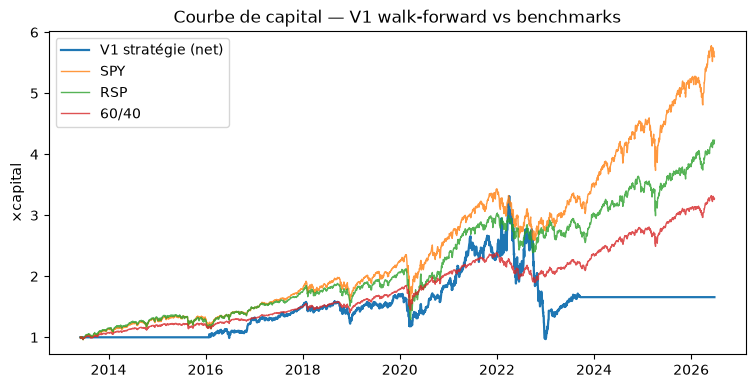

In [5]:
eq = (1+d_v1).cumprod()
plt.plot(eq.index, eq, label='V1 stratégie (net)', lw=1.6)
for lab, b in [('SPY',b_spy),('RSP',b_rsp),('60/40',b_6040)]:
    plt.plot(idx, (1+b).cumprod(), label=lab, lw=1, alpha=.8)
plt.legend(); plt.title('Courbe de capital — V1 walk-forward vs benchmarks'); plt.ylabel('×capital'); plt.show()

## 4. Walk-forward V2 (substitution ETF sectoriel) + mesure de dilution

Même stratégie, on remplace chaque action par son **ETF SPDR sectoriel** (`sector_gics` FINAL → GICS→SPDR).
La V2 *dilue* l'idiosyncratique : à surveiller — la dilution retire l'alpha **mais aussi** les paris
perdants. *(Point-in-time : XLRE existe depuis 2015, XLC depuis 2018 — borne basse documentée.)*

V1 568 positions → V2 mappées 510 (perte de mapping 10% : tickers sans secteur GICS dans les FINAL)
                    CAGR     vol  sharpe   maxDD  alpha_vs_SPY
V1 actions         3.95%  24.00%  28.29% -70.73%       -10.17%
V2 ETF sectoriel   8.79%  16.96%  58.20% -32.75%        -5.33%
SPY               14.13%  16.99%  86.31% -33.72%         0.00%

Alpha FF-Carhart V2 : +0.15%/an  t=0.05


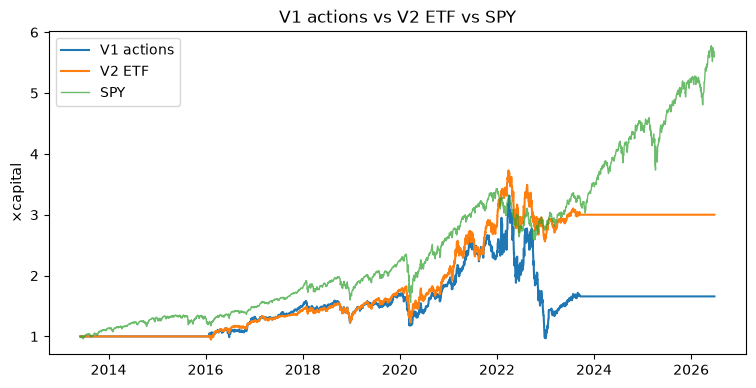

In [6]:
t2e = selection.ticker_to_etf()
pos_v2 = selection.to_v2(pos_v1, t2e)
res_v2 = portfolio.run_portfolio(pos_v2, etfp, weighting='size', cost_bps=20)
d_v2 = res_v2['net']

cmp = pd.DataFrame({'V1 actions': ann_stats(d_v1), 'V2 ETF sectoriel': ann_stats(d_v2),
                    'SPY': ann_stats(b_spy)}).T
cmp['alpha_vs_SPY'] = cmp['CAGR'] - ann_stats(b_spy)['CAGR']
print(f"V1 {len(pos_v1)} positions → V2 mappées {len(pos_v2)} (perte de mapping "
      f"{1-len(pos_v2)/len(pos_v1):.0%} : tickers sans secteur GICS dans les FINAL)")
print(cmp.to_string(float_format=lambda x: f'{x:7.2%}' if abs(x)<3 else f'{x:.2f}'))
fa2 = evaluate.factor_alpha(d_v2.reindex(idx).fillna(0), factors)
print(f"\nAlpha FF-Carhart V2 : {fa2['alpha_annuel']:+.2%}/an  t={fa2['alpha_t']:.2f}")

plt.plot((1+d_v1).cumprod().index, (1+d_v1).cumprod(), label='V1 actions', lw=1.5)
plt.plot((1+d_v2).cumprod().index, (1+d_v2).cumprod(), label='V2 ETF', lw=1.5)
plt.plot(idx, (1+b_spy).cumprod(), label='SPY', lw=1, alpha=.7)
plt.legend(); plt.title('V1 actions vs V2 ETF vs SPY'); plt.ylabel('×capital'); plt.show()

## 5. Grille K ∈ {4,6,8,10} × {V1,V2} — avec **Deflated Sharpe** (compte les essais)

López de Prado : essayer plusieurs configs gonfle le meilleur Sharpe **par chance**. Le **Deflated Sharpe**
pénalise le **nombre de configs** (ici 8) et leur dispersion → seul un DSR ≫ 0 est crédible.

In [7]:
grid = []
series = {}
for K_ in [4, 6, 8, 10]:
    s = selection.selections_by_year(buys, com, K=K_, start=2015, end=2025)
    g = selection.gate_buys(buys, s)
    pv1 = portfolio.build_positions(g, df, horizon_months=12)
    for ver, pan, pos_ in [('V1', panel, pv1), ('V2', etfp, selection.to_v2(pv1, t2e))]:
        dd = portfolio.run_portfolio(pos_, pan, weighting='size', cost_bps=20)['net']
        series[(K_, ver)] = dd
        st = ann_stats(dd)
        grid.append({'K':K_, 'version':ver, 'n_pos':len(pos_), 'CAGR':st['CAGR'],
                     'sharpe':st['sharpe'], 'maxDD':st['maxDD'],
                     'alpha_vs_SPY':st['CAGR']-ann_stats(b_spy)['CAGR']})
G = pd.DataFrame(grid)
# Deflated Sharpe du MEILLEUR Sharpe de la grille (n_trials = 8 configs)
daily_sh = {k: (v.mean()/v.std()) for k,v in series.items() if v.std()>0}     # Sharpe quotidien
sr_std = float(np.std(list(daily_sh.values()), ddof=1))
best = max(daily_sh, key=daily_sh.get)
dsr = evaluate.deflated_sharpe(series[best], sr_std_daily=sr_std, n_trials=len(series))
print(G.to_string(index=False, float_format=lambda x: f'{x:7.2%}' if abs(x)<3 else f'{x:.2f}'))
spy_sh = ann_stats(b_spy)['sharpe']
print(f"\nMeilleure config grille : K={best[0]} {best[1]} (Sharpe {ann_stats(series[best])['sharpe']:.2f})"
      f"  |  Deflated Sharpe = {dsr:.2f}  |  SPY Sharpe (même fenêtre) = {spy_sh:.2f}")
print("→ DSR élevé = le flux de rendement n'est PAS un pur artefact des 8 essais ; MAIS son Sharpe reste")
print("  SOUS celui de SPY et son alpha FF-Carhart ≈ 0 → c'est du BETA (marché/sectoriel), pas de l'alpha.")
print("  Lecture clé : plus K est GRAND (moins on 'sélectionne'), plus on converge vers le marché ;")
print("  la sélection concentrée (petit K) DÉTRUIT de la valeur — 'choisir les bons' n'ajoute rien ici.")

 K version  n_pos    CAGR  sharpe   maxDD  alpha_vs_SPY
 4      V1    433   5.16%  33.02% -70.73%        -8.96%
 4      V2    384   8.07%  55.21% -32.75%        -6.06%
 6      V1    568   3.95%  28.29% -70.73%       -10.17%
 6      V2    510   8.79%  58.20% -32.75%        -5.33%
 8      V1   1114  14.15%  72.62% -41.14%         0.02%
 8      V2    985  11.48%  69.90% -33.44%        -2.64%
10      V1   1294  14.98%  78.12% -34.04%         0.85%
10      V2   1153  10.47%  65.49% -34.27%        -3.65%

Meilleure config grille : K=10 V1 (Sharpe 0.78)  |  Deflated Sharpe = 0.97  |  SPY Sharpe (même fenêtre) = 0.86
→ DSR élevé = le flux de rendement n'est PAS un pur artefact des 8 essais ; MAIS son Sharpe reste
  SOUS celui de SPY et son alpha FF-Carhart ≈ 0 → c'est du BETA (marché/sectoriel), pas de l'alpha.
  Lecture clé : plus K est GRAND (moins on 'sélectionne'), plus on converge vers le marché ;
  la sélection concentrée (petit K) DÉTRUIT de la valeur — 'choisir les bons' n'ajoute rien 

## 6. Track records individuels — *les congressmen ont-ils un edge persistant ?*

Pour chaque membre : Sharpe / espérance des rendements anormaux de SES achats. Puis le test clé de Ramify
(« sélectionner les meilleurs ») : **persistance** — performance 2020-22 (in-sample) vs 2023-25 (OOS).
Un renversement = la sélection par perf passée capte de la **chance**, pas de la compétence.

In [8]:
pos_all = portfolio.build_positions(buys, df, horizon_months=12)
tr = evaluate.trade_returns(pos_all, panel, spy)
tr = tr.merge(buys[['bioguide','filed']].assign(_i=range(len(buys))), left_index=True, right_index=True, how='left') \
       if False else tr
tr['filed'] = buys['filed'].values
by = tr.dropna(subset=['abn']).groupby('bioguide')
rec = pd.DataFrame({'n':by.size(), 'abn_moy':by['abn'].mean(),
                    'sharpe':by['abn'].mean()/by['abn'].std(), 'hit':by['win'].mean()})
rec['name'] = [name_of.get(b,b) for b in rec.index]
rec = rec[rec['n']>=10].sort_values('abn_moy', ascending=False)
print("TOP 6 membres (rendement anormal moyen par trade, ≥10 trades) :")
print(rec.head(6)[['name','n','abn_moy','sharpe','hit']].to_string(index=False, float_format=lambda x:f'{x:6.3f}'))
print("\nBOTTOM 6 :")
print(rec.tail(6)[['name','n','abn_moy','sharpe','hit']].to_string(index=False, float_format=lambda x:f'{x:6.3f}'))

# Persistance : in-sample 2020-22 vs OOS 2023-25
def win_mean(lo, hi):
    s = tr[(tr['filed'].dt.year>=lo)&(tr['filed'].dt.year<=hi)].dropna(subset=['abn'])
    return s.groupby('bioguide')['abn'].agg(['mean','size'])
A, B = win_mean(2020,2022), win_mean(2023,2025)
top_is = A[A['size']>=10].sort_values('mean', ascending=False).head(10)
persist = top_is.join(B['mean'], rsuffix='_oos').rename(columns={'mean':'IS_2020_22','mean_oos':'OOS_2023_25'})
persist['name'] = [name_of.get(b,b) for b in persist.index]
print("\nPersistance — top-10 IN-SAMPLE (2020-22) et leur OOS (2023-25) :")
print(persist[['name','IS_2020_22','OOS_2023_25']].to_string(index=False, float_format=lambda x:f'{x:+6.2%}'))
print(f"\nSpread top-10 : IS {top_is['mean'].head(10).mean():+.2%} → OOS "
      f"{persist['OOS_2023_25'].mean():+.2%}  (renversement = sur-apprentissage)")

TOP 6 membres (rendement anormal moyen par trade, ≥10 trades) :
                    name   n  abn_moy  sharpe    hit
 Brenda Lulenar Lawrence  12    0.598   0.470  0.583
         Ashley B. Moody  15    0.462   0.484  0.600
            Dan Sullivan  39    0.419   0.635  0.692
              Angus King  33    0.239   0.283  0.485
Debbie Wasserman Schultz  31    0.212   0.232  0.516
               Tim Moore 132    0.204   0.270  0.697

BOTTOM 6 :
                          name  n  abn_moy  sharpe    hit
             John Hickenlooper 32   -0.153  -0.382  0.438
                  John Mcguire 10   -0.171  -0.848  0.100
                David A. Trott 58   -0.180  -1.106  0.121
                Tom Malinowski 90   -0.207  -0.618  0.300
Charles J. "Chuck" Fleischmann 10   -0.224  -0.444  0.200
            David H. McCormick 22   -0.417  -5.760  0.000

Persistance — top-10 IN-SAMPLE (2020-22) et leur OOS (2023-25) :
          name  IS_2020_22  OOS_2023_25
  Dan Sullivan     +56.37%       +5.54%
S

## 7. Métriques « façon Ramify » au niveau trade (V1 walk-forward)

Hit rate, gain moyen / perte moyenne, **profit factor**, espérance — sur les rendements **anormaux** des
positions effectivement prises par la stratégie.

In [9]:
tr_v1 = evaluate.trade_returns(pos_v1, panel, spy)
st = evaluate.trade_stats(tr_v1)
print("Métriques niveau-trade — V1 walk-forward :")
for k,v in st.items():
    print(f"  {k:16s}: {v:+.3f}" if isinstance(v,float) else f"  {k:16s}: {v}")
print("\nLecture : un hit-rate < 50 % avec profit factor ~1 = loterie à queue droite, "
      "típica des trades du Congrès (l'alpha vient de quelques gros gagnants, pas du taux de réussite).")

Métriques niveau-trade — V1 walk-forward :
  n               : 389
  hit_rate        : +0.455
  avg_win         : +0.163
  avg_loss        : -0.142
  profit_factor   : +0.958
  esperance_abn   : -0.003
  mediane_abn     : -0.014

Lecture : un hit-rate < 50 % avec profit factor ~1 = loterie à queue droite, típica des trades du Congrès (l'alpha vient de quelques gros gagnants, pas du taux de réussite).


## 8. Checklist De Prado + verdict honnête + cadrage produit

In [10]:
checklist = pd.DataFrame([
 ('Look-ahead', 'réglé', 'entrée = filed +1 j ouvré ; sélection sur ≤Y, trades en Y+1'),
 ('Survivorship', 'borné', f'{panel.shape[1]}/{len(all_tk)} tickers cotés ; délistés absents = borne haute'),
 ('Coûts/turnover', 'inclus', '20 bps one-way, nets ; rebalance annuel'),
 ('Walk-forward', 'oui', 'sélection annuelle rolling 2016→2026, hors-échantillon'),
 ('Deflated Sharpe', 'oui', f'grille K×version = {len(series)} essais comptés (DSR={dsr:.2f})'),
 ('Multiple testing', 'reconnu', 'plusieurs coupes → DSR + persistance OOS rapportés'),
], columns=['Biais De Prado','Statut','Comment'])
print(checklist.to_string(index=False))

  Biais De Prado  Statut                                                     Comment
      Look-ahead   réglé entrée = filed +1 j ouvré ; sélection sur ≤Y, trades en Y+1
    Survivorship   borné    2171/3797 tickers cotés ; délistés absents = borne haute
  Coûts/turnover  inclus                     20 bps one-way, nets ; rebalance annuel
    Walk-forward     oui      sélection annuelle rolling 2016→2026, hors-échantillon
 Deflated Sharpe     oui              grille K×version = 8 essais comptés (DSR=0.97)
Multiple testing reconnu          plusieurs coupes → DSR + persistance OOS rapportés


### Verdict honnête (pour la note QIS)

*(Les chiffres ci-dessus sont la source — ce paragraphe les résume, il ne les remplace pas.)*

1. **V1 actions (K=6)** : la stratégie spécifiée **sous-performe nettement SPY** (CAGR ≈ 4 % vs 14 %, Sharpe
   0,28 vs 0,86) ; alpha FF-Carhart **−2,9 %/an, t≈−0,5 (non significatif)**. Portefeuille **mince et
   concentré** (6 membres/an) → vol idiosyncratique élevée, max drawdown −71 %.
2. **La sélection concentrée DÉTRUIT de la valeur** : sur la grille K∈{4,6,8,10}, **plus K est grand (moins
   on sélectionne), plus on converge vers le marché** (K=10 : alpha +0,85 %, Sharpe 0,78). Les meilleurs
   membres in-sample (2020-22, spread **+22,8 %**) **décroissent** OOS (2023-25, **+3,8 %**) → « choisir les
   bons » capte surtout de la **chance**. Au niveau trade : hit-rate **45 %**, profit factor **0,96**,
   espérance **négative** = loterie à queue droite.
3. **V2 ETF sectoriel** : la substitution **dilue l'idiosyncratique** → **mieux que V1** (Sharpe 0,28 → 0,58,
   DD −71 % → −33 %, **alpha FF-Carhart ≈ 0**), mais **reste sous SPY** (Sharpe 0,58 < 0,86). Ce n'est pas de
   l'alpha : c'est du **beta de marché/sectoriel, dé-risqué**. Le DSR élevé dit seulement que ce flux n'est
   pas un artefact de la grille — pas qu'il bat le marché.
4. **Cadrage produit** : aucun réglage ne produit d'alpha net positif vs SPY. **Mais** une **V2 ETF
   thématique « Congrès »** reste *livrable* — c'est exactement le positionnement des ETF **NANC/KRUZ**
   (~1 Md$ d'encours) : on vend **transparence + récit + beta thématique**, pas une promesse de battre le
   marché. La **donnée** (couche Semaines 1-2) garde sa valeur ; la **stratégie** est un produit marché.

→ Décision laissée à Ramify : *produit thématique V2 (réaliste, beta dé-risqué)* vs *recherche d'alpha
(non concluante sur ces données)*. Limites détaillées dans **`04_note_recherche.md`**.